In [1]:
import os
import cv2
import time
import glob
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans
from skimage.segmentation import slic
from skimage.feature import local_binary_pattern
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

DATASET_ROOT = r"/Users/qijiazhou/Desktop/9517/group/9517_group/EWS-Dataset"
OUTPUT_ROOT = r"/Users/qijiazhou/Desktop/9517/group/Untitled/results_traditional_final_lbp"

N_SEGMENTS = 300
COMPACTNESS = 10
SIGMA = 1.0

LBP_RADIUS = 1
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"

MORPH_KERNEL_SIZE = 5
MIN_COMPONENT_AREA = 80

SEEDS = [0, 1, 2, 3, 4]

FEATURE_MODES = ["RGB", "LBP", "RGB_LBP"]
FINAL_FEATURE_MODE = "LBP"

POST_CONFIGS = [
    ("P0", "P0", MIN_COMPONENT_AREA),
    ("P1", "P1", MIN_COMPONENT_AREA),
    ("P2", "P2", MIN_COMPONENT_AREA),
    ("P3", "P3", MIN_COMPONENT_AREA),
    ("P3_area30", "P3", 30),
    ("P3_area80", "P3", 80),
]

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def read_img(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(path)
    return (mask > 127).astype(np.uint8)

def pair(folder):
    files = glob.glob(os.path.join(folder, "*.png"))
    imgs = []
    masks = {}
    for f in files:
        name = Path(f).stem
        if name.endswith("_mask"):
            masks[name[:-5]] = f
        else:
            imgs.append((name, f))
    pairs = [(img, masks[name]) for name, img in imgs if name in masks]
    if len(pairs) == 0:
        raise RuntimeError(f"No pairs found in {folder}")
    return sorted(pairs, key=lambda x: x[0])

def get_data():
    train_pairs = pair(os.path.join(DATASET_ROOT, "train"))
    val_pairs = pair(os.path.join(DATASET_ROOT, "validation"))
    test_pairs = pair(os.path.join(DATASET_ROOT, "test"))
    return train_pairs, val_pairs, test_pairs

def exg(img):
    x = img.astype(np.float32) / 255.0
    return 2.0 * x[:, :, 1] - x[:, :, 0] - x[:, :, 2]

def build_features(img, seg, feature_mode="RGB_LBP"):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)

    n_regions = int(seg.max()) + 1
    feats = []

    for i in range(n_regions):
        m = seg == i

        if np.sum(m) == 0:
            if feature_mode == "RGB":
                feats.append([0.0, 0.0, 0.0])
            elif feature_mode == "LBP":
                feats.append([0.0])
            elif feature_mode == "RGB_LBP":
                feats.append([0.0, 0.0, 0.0, 0.0])
            else:
                raise ValueError(f"Unknown feature_mode: {feature_mode}")
            continue

        if feature_mode == "RGB":
            f = [
                float(np.mean(img[:, :, 0][m])),
                float(np.mean(img[:, :, 1][m])),
                float(np.mean(img[:, :, 2][m]))
            ]
        elif feature_mode == "LBP":
            f = [
                float(np.mean(lbp[m]))
            ]
        elif feature_mode == "RGB_LBP":
            f = [
                float(np.mean(img[:, :, 0][m])),
                float(np.mean(img[:, :, 1][m])),
                float(np.mean(img[:, :, 2][m])),
                float(np.mean(lbp[m]))
            ]
        else:
            raise ValueError(f"Unknown feature_mode: {feature_mode}")

        feats.append(f)

    feats = np.array(feats, dtype=np.float32)
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

    mu = np.mean(feats, axis=0, keepdims=True)
    sd = np.std(feats, axis=0, keepdims=True)
    sd[sd < 1e-6] = 1.0
    feats = (feats - mu) / sd
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    return feats

def postprocess(mask, post_mode="P3", min_component_area=MIN_COMPONENT_AREA):
    m = (mask * 255).astype(np.uint8)

    if post_mode in ["P1", "P3"]:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE))
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)

    if post_mode in ["P2", "P3"]:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
        cleaned = np.zeros_like(m)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= min_component_area:
                cleaned[labels == i] = 255
        m = cleaned

    return (m > 127).astype(np.uint8)

def fallback_segment(img, post_mode="P0", min_component_area=MIN_COMPONENT_AREA):
    e = exg(img)
    thr = float(np.mean(e))
    pred = (e > thr).astype(np.uint8)
    return postprocess(pred, post_mode, min_component_area)

def segment_image(img, seed, feature_mode="RGB_LBP", post_mode="P0", min_component_area=MIN_COMPONENT_AREA):
    seg = slic(
        img.astype(np.float32) / 255.0,
        n_segments=N_SEGMENTS,
        compactness=COMPACTNESS,
        sigma=SIGMA,
        start_label=0
    )

    n_regions = int(seg.max()) + 1
    if n_regions < 2:
        return fallback_segment(img, post_mode, min_component_area)

    feats = build_features(img, seg, feature_mode)
    if feats.shape[0] < 2:
        return fallback_segment(img, post_mode, min_component_area)

    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    labels = km.fit_predict(feats)

    e = exg(img)
    scores = []
    for i in range(2):
        ids = np.where(labels == i)[0]
        if len(ids) == 0:
            scores.append(-1e9)
            continue
        m = np.isin(seg, ids)
        if np.sum(m) == 0:
            scores.append(-1e9)
            continue
        scores.append(float(np.mean(e[m])))

    crop_cluster = int(np.argmax(scores))
    pred = np.zeros(seg.shape, dtype=np.uint8)
    for i in np.where(labels == crop_cluster)[0]:
        pred[seg == i] = 1

    return postprocess(pred, post_mode, min_component_area)

def evaluate(gt, pred):
    g = gt.flatten()
    p = pred.flatten()
    return [
        precision_score(g, p, zero_division=0),
        recall_score(g, p, zero_division=0),
        f1_score(g, p, zero_division=0),
        jaccard_score(g, p, zero_division=0)
    ]

def overlay(img, mask):
    out = img.copy()
    green = np.zeros_like(out)
    green[:, :, 1] = 255
    alpha = 0.4
    out[mask == 1] = (alpha * green[mask == 1] + (1 - alpha) * out[mask == 1]).astype(np.uint8)
    return out

def format_metric(mean, std):
    return f"{mean:.4f}±{std:.4f}"

def save_table_txt(path, headers, rows):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\t".join(headers) + "\n")
        for row in rows:
            f.write("\t".join(str(x) for x in row) + "\n")

def print_metrics(title, mean, std):
    print(title)
    print(f"Precision mean={mean[0]:.4f} std={std[0]:.4f}")
    print(f"Recall    mean={mean[1]:.4f} std={std[1]:.4f}")
    print(f"F1        mean={mean[2]:.4f} std={std[2]:.4f}")
    print(f"IoU       mean={mean[3]:.4f} std={std[3]:.4f}")
    print(f"Time      mean={mean[4]:.4f} std={std[4]:.4f}")
    print()

def run_experiment(
    pairs,
    feature_mode="RGB_LBP",
    post_mode="P0",
    min_component_area=MIN_COMPONENT_AREA,
    save_dir=None,
    save_images=False
):
    if save_dir is not None:
        ensure_dir(save_dir)

    all_metrics = []

    for seed in SEEDS:
        seed_metrics = []

        for img_p, mask_p in pairs:
            img = read_img(img_p)
            gt = read_mask(mask_p)

            t = time.time()
            pred = segment_image(
                img,
                seed=seed,
                feature_mode=feature_mode,
                post_mode=post_mode,
                min_component_area=min_component_area
            )
            dt = time.time() - t

            p, r, f, i = evaluate(gt, pred)
            seed_metrics.append([p, r, f, i, dt])

            if save_images and save_dir is not None and seed == SEEDS[0]:
                base = Path(img_p).stem
                cv2.imwrite(os.path.join(save_dir, base + "_pred.png"), (pred * 255).astype(np.uint8))
                ov = overlay(img, pred)
                cv2.imwrite(os.path.join(save_dir, base + "_overlay.png"), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))

        all_metrics.append(np.mean(seed_metrics, axis=0))

    all_metrics = np.array(all_metrics, dtype=np.float32)
    return np.mean(all_metrics, axis=0), np.std(all_metrics, axis=0)

def distort(img, kind=None, severity=None, rng=None):
    if kind is None or severity is None:
        return img.copy()

    if rng is None:
        rng = np.random.default_rng()

    if kind == "noise":
        noise = rng.normal(0, severity, img.shape)
        out = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        return out

    if kind == "blur":
        k = int(severity)
        if k % 2 == 0:
            k += 1
        return cv2.GaussianBlur(img, (k, k), 0)

    if kind == "dark":
        factor = float(severity)
        out = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        return out

    return img.copy()

def run_robustness(
    pairs,
    distortion_type,
    severity_levels,
    save_root=None
):
    rows = []

    for severity in severity_levels:
        all_metrics = []

        for seed in SEEDS:
            seed_metrics = []
            rng = np.random.default_rng(seed)

            for img_p, mask_p in pairs:
                img = read_img(img_p)
                img = distort(img, distortion_type, severity, rng=rng)
                gt = read_mask(mask_p)

                t = time.time()
                pred = segment_image(
                    img,
                    seed=seed,
                    feature_mode=FINAL_FEATURE_MODE,
                    post_mode="P0",
                    min_component_area=MIN_COMPONENT_AREA
                )
                dt = time.time() - t

                p, r, f, i = evaluate(gt, pred)
                seed_metrics.append([p, r, f, i, dt])

            all_metrics.append(np.mean(seed_metrics, axis=0))

        all_metrics = np.array(all_metrics, dtype=np.float32)
        mean = np.mean(all_metrics, axis=0)
        std = np.std(all_metrics, axis=0)

        print_metrics(f"{distortion_type} severity={severity}", mean, std)

        rows.append([
            distortion_type,
            str(severity),
            format_metric(mean[0], std[0]),
            format_metric(mean[1], std[1]),
            format_metric(mean[2], std[2]),
            format_metric(mean[3], std[3]),
            format_metric(mean[4], std[4]),
        ])

    if save_root is not None:
        ensure_dir(save_root)
        save_table_txt(
            os.path.join(save_root, f"{distortion_type}_robustness_table.txt"),
            ["Distortion", "Severity", "Precision", "Recall", "F1", "IoU", "Time"],
            rows
        )

def feature_engineering_ablation(test_pairs):
    rows = []
    for feature_mode in FEATURE_MODES:
        mean, std = run_experiment(
            test_pairs,
            feature_mode=feature_mode,
            post_mode="P0",
            save_dir=os.path.join(OUTPUT_ROOT, "feature_engineering", feature_mode),
            save_images=(feature_mode == FINAL_FEATURE_MODE)
        )
        print_metrics(f"Feature Engineering - {feature_mode}", mean, std)
        rows.append([
            feature_mode,
            format_metric(mean[0], std[0]),
            format_metric(mean[1], std[1]),
            format_metric(mean[2], std[2]),
            format_metric(mean[3], std[3]),
            format_metric(mean[4], std[4]),
        ])

    save_table_txt(
        os.path.join(OUTPUT_ROOT, "feature_engineering_table.txt"),
        ["Mode", "Precision", "Recall", "F1", "IoU", "Time"],
        rows
    )

def postprocessing_ablation(test_pairs):
    rows = []
    for name, post_mode, area in POST_CONFIGS:
        mean, std = run_experiment(
            test_pairs,
            feature_mode=FINAL_FEATURE_MODE,
            post_mode=post_mode,
            min_component_area=area,
            save_dir=os.path.join(OUTPUT_ROOT, "postprocessing", name),
            save_images=(name == "P3")
        )
        print_metrics(f"Post-processing - {name}", mean, std)
        rows.append([
            name,
            format_metric(mean[0], std[0]),
            format_metric(mean[1], std[1]),
            format_metric(mean[2], std[2]),
            format_metric(mean[3], std[3]),
            format_metric(mean[4], std[4]),
        ])

    save_table_txt(
        os.path.join(OUTPUT_ROOT, "postprocessing_table.txt"),
        ["Mode", "Precision", "Recall", "F1", "IoU", "Time"],
        rows
    )

def final_result(test_pairs):
    mean, std = run_experiment(
        test_pairs,
        feature_mode=FINAL_FEATURE_MODE,
        post_mode="P0",
        save_dir=os.path.join(OUTPUT_ROOT, "final_result"),
        save_images=True
    )

    print_metrics(f"Final Result - {FINAL_FEATURE_MODE} + P0", mean, std)

    save_table_txt(
        os.path.join(OUTPUT_ROOT, "final_result_table.txt"),
        ["Mode", "Precision", "Recall", "F1", "IoU", "Time"],
        [[
            f"{FINAL_FEATURE_MODE} + P0",
            format_metric(mean[0], std[0]),
            format_metric(mean[1], std[1]),
            format_metric(mean[2], std[2]),
            format_metric(mean[3], std[3]),
            format_metric(mean[4], std[4]),
        ]]
    )

def robustness_experiments(test_pairs):
    robustness_root = os.path.join(OUTPUT_ROOT, "robustness")
    ensure_dir(robustness_root)

    run_robustness(
        test_pairs,
        distortion_type="noise",
        severity_levels=[0, 10, 20, 30],
        save_root=robustness_root
    )

    run_robustness(
        test_pairs,
        distortion_type="blur",
        severity_levels=[1, 3, 5, 7],
        save_root=robustness_root
    )

    run_robustness(
        test_pairs,
        distortion_type="dark",
        severity_levels=[1.0, 0.8, 0.6, 0.4],
        save_root=robustness_root
    )

def main():
    ensure_dir(OUTPUT_ROOT)

    train_pairs, val_pairs, test_pairs = get_data()

    print("Pairs:")
    print("Train:", len(train_pairs))
    print("Validation:", len(val_pairs))
    print("Test:", len(test_pairs))
    print()

    feature_engineering_ablation(test_pairs)
    postprocessing_ablation(test_pairs)
    final_result(test_pairs)
    robustness_experiments(test_pairs)

if __name__ == "__main__":
    main()


Pairs:
Train: 142
Validation: 24
Test: 24

Feature Engineering - RGB
Precision mean=0.5438 std=0.0000
Recall    mean=0.3680 std=0.0001
F1        mean=0.4297 std=0.0001
IoU       mean=0.3004 std=0.0001
Time      mean=0.1104 std=0.0029

Feature Engineering - LBP
Precision mean=0.5712 std=0.0000
Recall    mean=0.3912 std=0.0001
F1        mean=0.4514 std=0.0001
IoU       mean=0.3122 std=0.0001
Time      mean=0.0933 std=0.0070

Feature Engineering - RGB_LBP
Precision mean=0.5463 std=0.0002
Recall    mean=0.3684 std=0.0005
F1        mean=0.4319 std=0.0003
IoU       mean=0.3016 std=0.0004
Time      mean=0.1097 std=0.0005

Post-processing - P0
Precision mean=0.5712 std=0.0000
Recall    mean=0.3912 std=0.0001
F1        mean=0.4514 std=0.0001
IoU       mean=0.3122 std=0.0001
Time      mean=0.0962 std=0.0037

Post-processing - P1
Precision mean=0.5730 std=0.0000
Recall    mean=0.3888 std=0.0002
F1        mean=0.4502 std=0.0001
IoU       mean=0.3110 std=0.0001
Time      mean=0.0973 std=0.0009

Pos

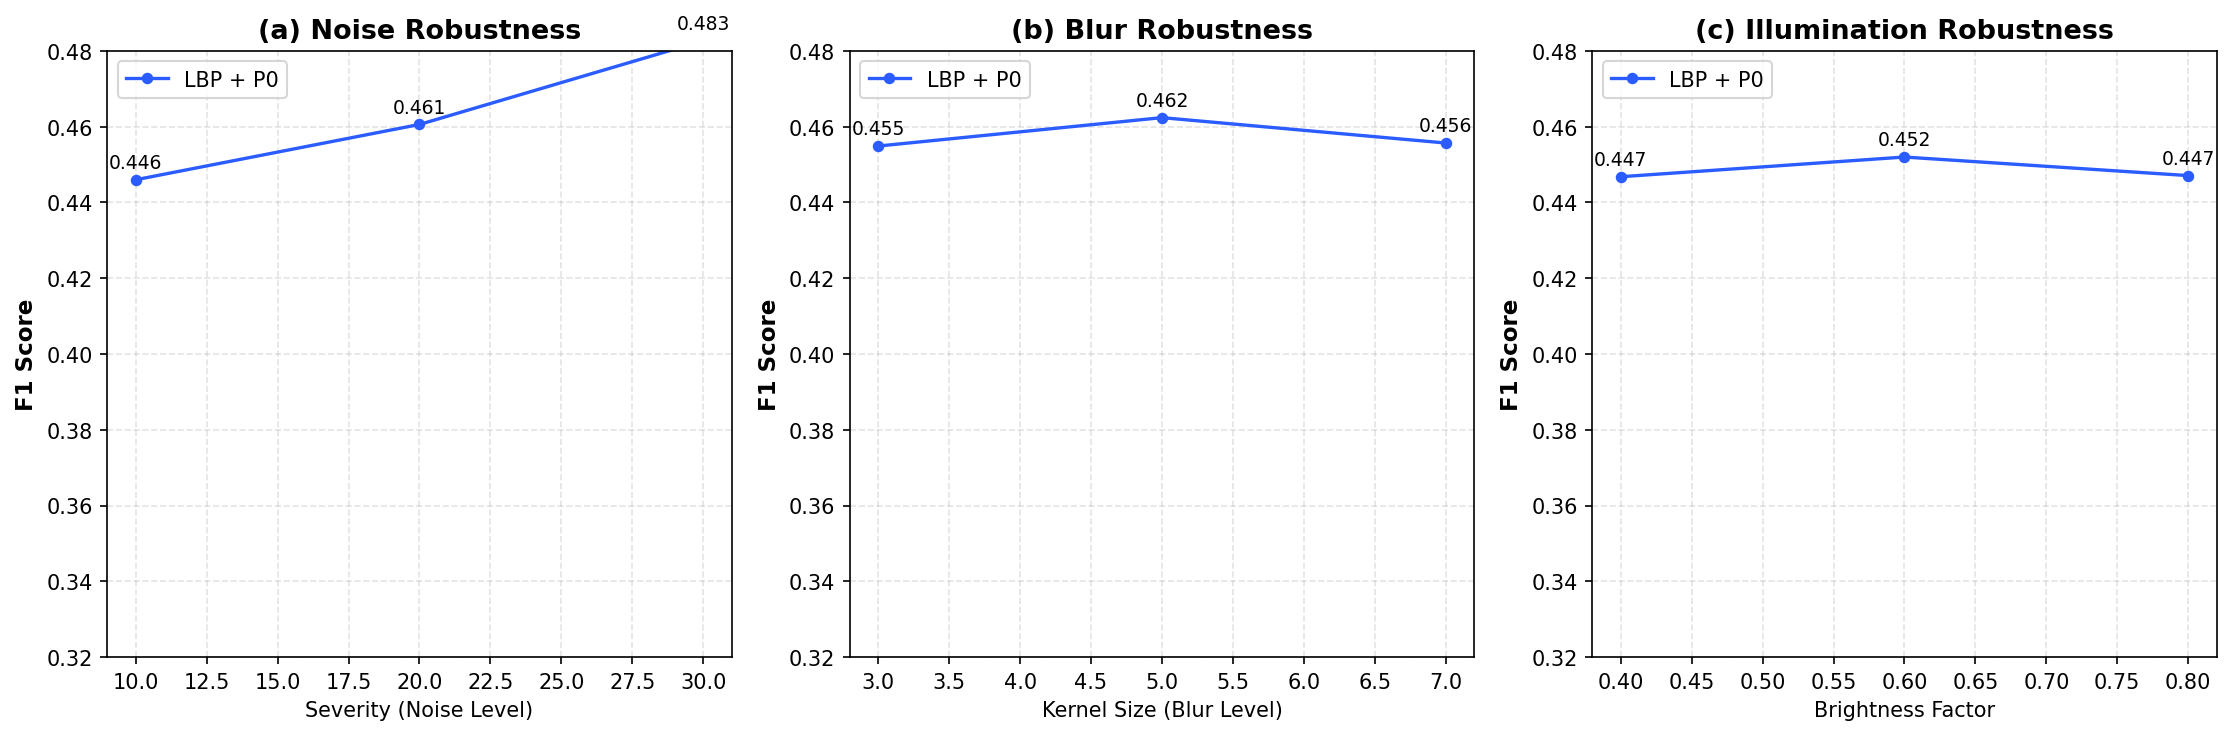

Saved figure to: /Users/qijiazhou/Desktop/9517/group/Untitled/results_traditional_final_lbp/robustness/robustness_f1_curves.png


In [3]:
# Robustness Curves Plot
import os
import matplotlib.pyplot as plt

def _parse_f1_mean(metric_str):
    # metric format: "0.4032±0.0011"
    return float(str(metric_str).split('±')[0])

def _load_curve(table_path):
    xs, ys = [], []
    with open(table_path, 'r', encoding='utf-8') as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    for ln in lines[1:]:
        parts = ln.split('\t')
        severity = float(parts[1])
        f1_mean = _parse_f1_mean(parts[4])
        xs.append(severity)
        ys.append(f1_mean)
    return xs, ys

robustness_root = os.path.join(OUTPUT_ROOT, 'robustness')
noise_x, noise_y = _load_curve(os.path.join(robustness_root, 'noise_robustness_table.txt'))
blur_x, blur_y = _load_curve(os.path.join(robustness_root, 'blur_robustness_table.txt'))
dark_x, dark_y = _load_curve(os.path.join(robustness_root, 'dark_robustness_table.txt'))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
line_label = f'{FINAL_FEATURE_MODE} + P0'

plots = [
    (axes[0], noise_x, noise_y, '(a) Noise Robustness', 'Severity (Noise Level)'),
    (axes[1], blur_x, blur_y, '(b) Blur Robustness', 'Kernel Size (Blur Level)'),
    (axes[2], dark_x, dark_y, '(c) Illumination Robustness', 'Brightness Factor'),
]

for ax, xs, ys, title, xlabel in plots:
    ax.plot(xs, ys, marker='o', linewidth=1.6, markersize=4.5, color='#2a5cff', label=line_label)
    for x, y in zip(xs, ys):
        ax.text(x, y + 0.002, f'{y:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
    ax.set_ylim(0.32, 0.48)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='upper left', fontsize=10, frameon=True)

# For darkening, lower brightness factor means stronger disturbance.
axes[2].invert_xaxis()

plt.tight_layout()
fig_path = os.path.join(robustness_root, 'robustness_f1_curves.png')
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print('Saved figure to:', fig_path)




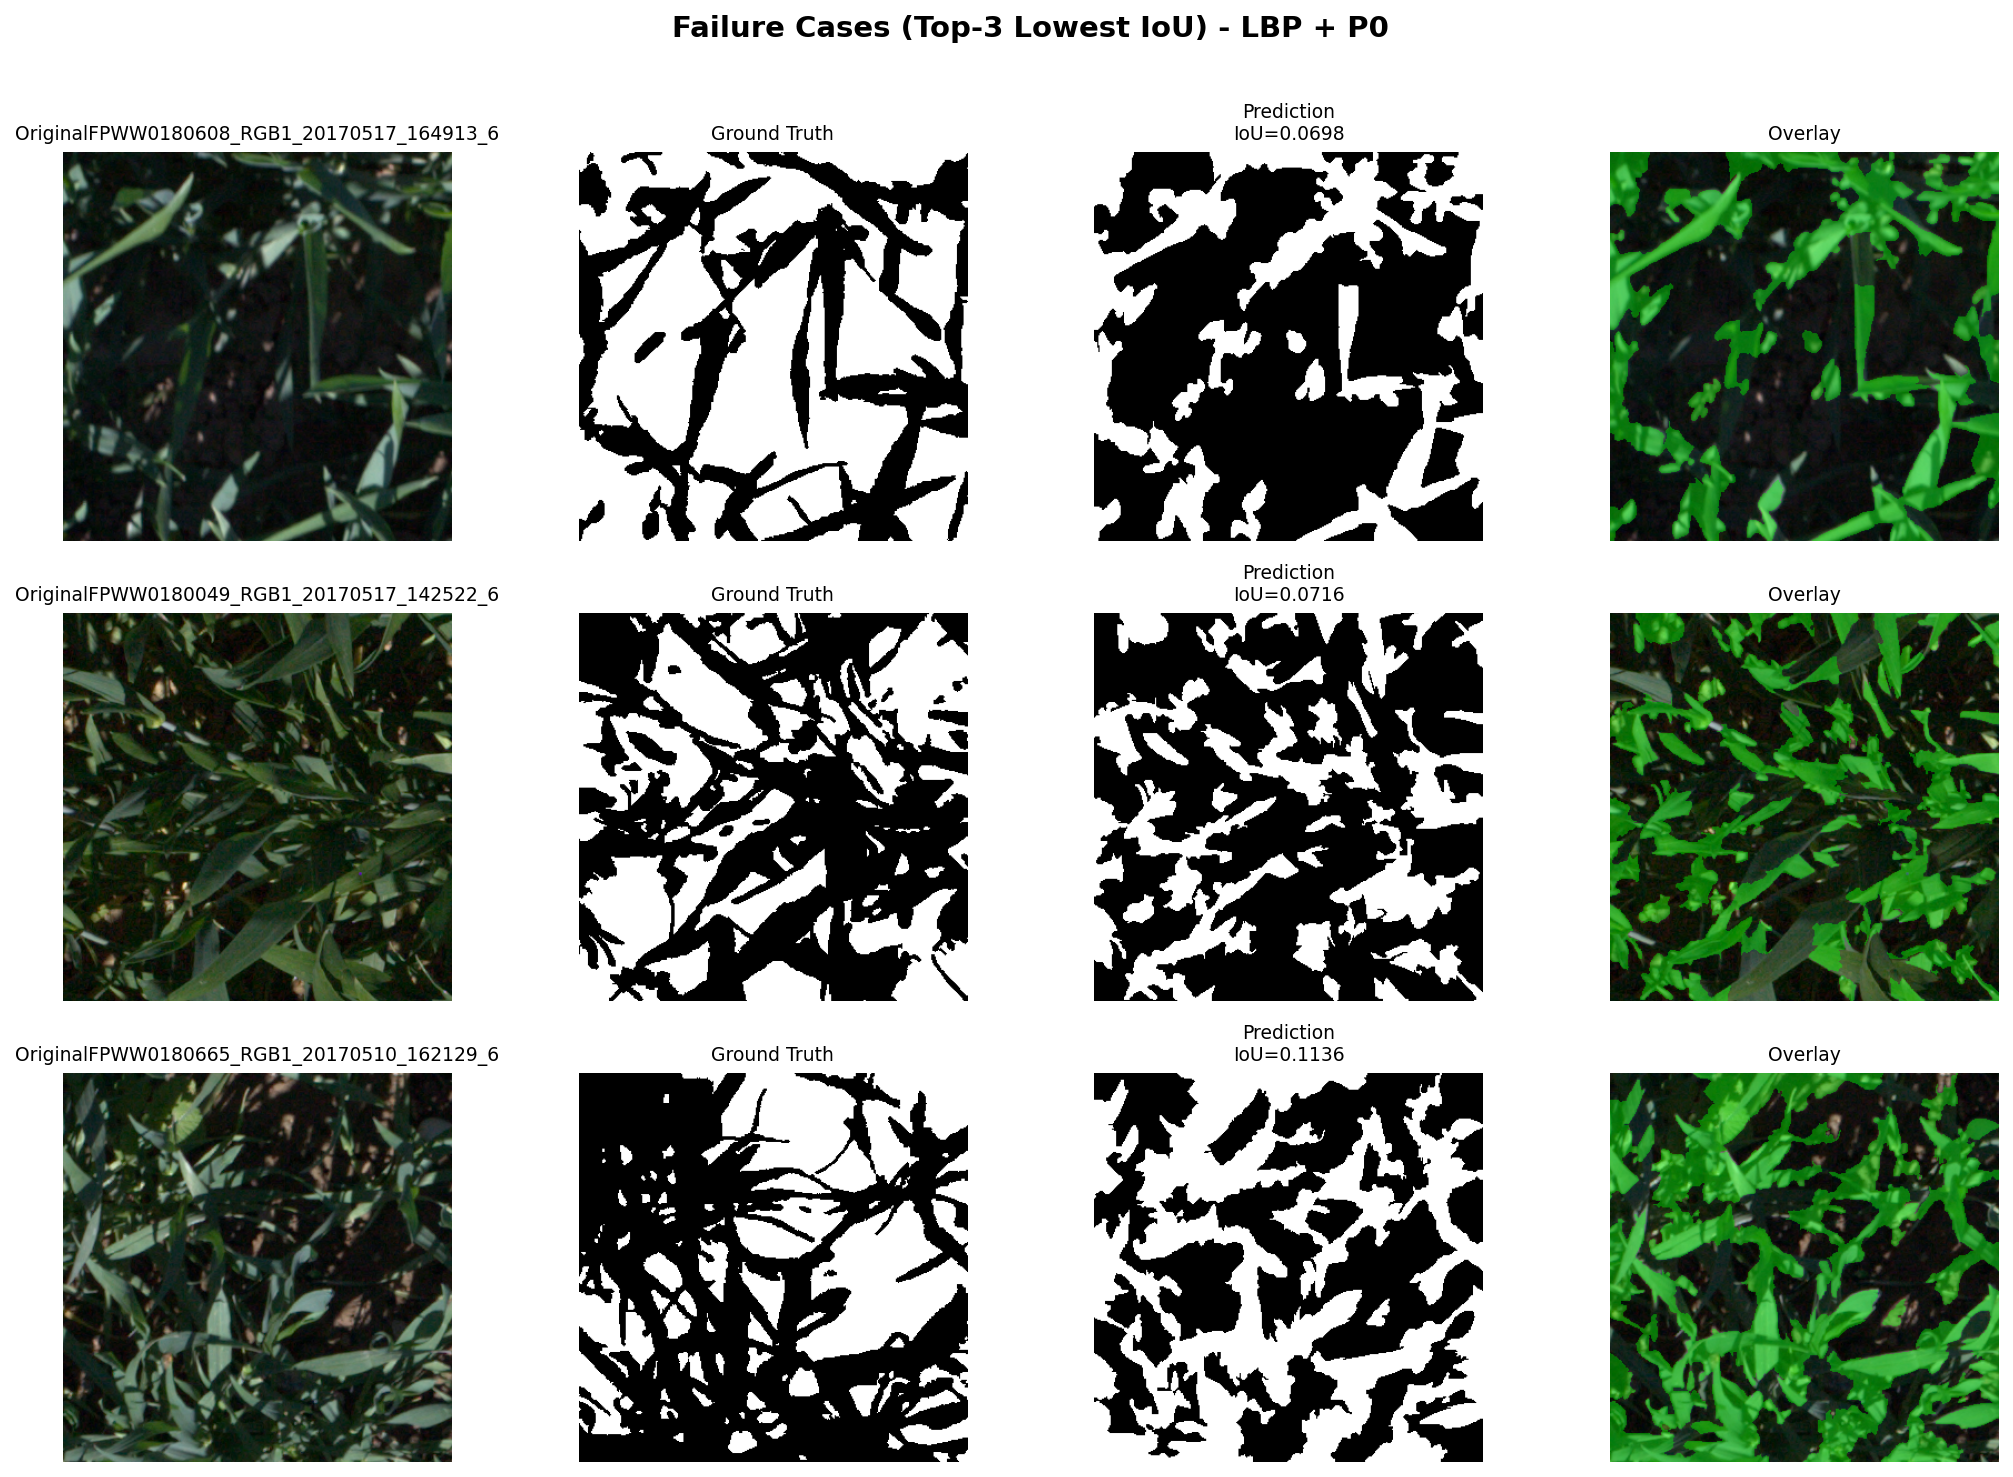

Saved summary: /Users/qijiazhou/Desktop/9517/group/Untitled/results_traditional_final_lbp/failure_cases_top3/failure_cases_top3_summary.png
Saved case panel: /Users/qijiazhou/Desktop/9517/group/Untitled/results_traditional_final_lbp/failure_cases_top3/failure_case_1_panel.png
Saved case panel: /Users/qijiazhou/Desktop/9517/group/Untitled/results_traditional_final_lbp/failure_cases_top3/failure_case_2_panel.png
Saved case panel: /Users/qijiazhou/Desktop/9517/group/Untitled/results_traditional_final_lbp/failure_cases_top3/failure_case_3_panel.png


In [7]:
# Failure Cases Top3
import os
import matplotlib.pyplot as plt


def save_failure_cases_top3(test_pairs, seed=0):
    out_dir = os.path.join(OUTPUT_ROOT, 'failure_cases_top3')
    ensure_dir(out_dir)

    records = []
    for img_p, mask_p in test_pairs:
        img = read_img(img_p)
        gt = read_mask(mask_p)
        pred = segment_image(
            img,
            seed=seed,
            feature_mode=FINAL_FEATURE_MODE,
            post_mode='P0',
            min_component_area=MIN_COMPONENT_AREA
        )
        iou = jaccard_score(gt.flatten(), pred.flatten(), zero_division=0)
        records.append((iou, img_p, img, gt, pred))

    records.sort(key=lambda x: x[0])  # lowest IoU first
    worst3 = records[:3]

    # Save a summary figure (3 rows x 4 cols)
    fig, axes = plt.subplots(3, 4, figsize=(14, 10), dpi=150)
    fig.suptitle(f'Failure Cases (Top-3 Lowest IoU) - {FINAL_FEATURE_MODE} + P0', fontsize=14, fontweight='bold')

    for r, (iou, img_p, img, gt, pred) in enumerate(worst3):
        ov = overlay(img, pred)
        base = Path(img_p).stem

        # save single-case panel image too
        case_fig, case_axes = plt.subplots(1, 4, figsize=(14, 3.2), dpi=150)
        panels = [
            ('Original', img),
            ('Ground Truth', gt),
            ('Prediction', pred),
            ('Overlay', ov),
        ]
        for j, (title, panel) in enumerate(panels):
            if title in ['Ground Truth', 'Prediction']:
                case_axes[j].imshow(panel, cmap='gray')
            else:
                case_axes[j].imshow(panel)
            case_axes[j].set_title(title, fontsize=10)
            case_axes[j].axis('off')
        case_fig.suptitle(f'{base} | IoU={iou:.4f}', fontsize=11)
        case_fig.tight_layout()
        case_path = os.path.join(out_dir, f'failure_case_{r+1}_panel.png')
        case_fig.savefig(case_path, bbox_inches='tight')
        plt.close(case_fig)

        # fill summary grid
        axes[r, 0].imshow(img)
        axes[r, 0].set_title(f'Original{base}', fontsize=9)
        axes[r, 0].axis('off')

        axes[r, 1].imshow(gt, cmap='gray')
        axes[r, 1].set_title('Ground Truth', fontsize=9)
        axes[r, 1].axis('off')

        axes[r, 2].imshow(pred, cmap='gray')
        axes[r, 2].set_title(f'Prediction\nIoU={iou:.4f}', fontsize=9)
        axes[r, 2].axis('off')

        axes[r, 3].imshow(ov)
        axes[r, 3].set_title('Overlay', fontsize=9)
        axes[r, 3].axis('off')

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    summary_path = os.path.join(out_dir, 'failure_cases_top3_summary.png')
    fig.savefig(summary_path, bbox_inches='tight')
    plt.show()

    print('Saved summary:', summary_path)
    for i in range(3):
        print('Saved case panel:', os.path.join(out_dir, f'failure_case_{i+1}_panel.png'))


# Run (requires test_pairs from main notebook context)
_, _, test_pairs = get_data()
save_failure_cases_top3(test_pairs, seed=0)

